<a href="https://colab.research.google.com/github/Priya-Kumari-Chourasia/ml_algo/blob/main/ridge_regression_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
x,y = make_regression(n_samples=200,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=23)

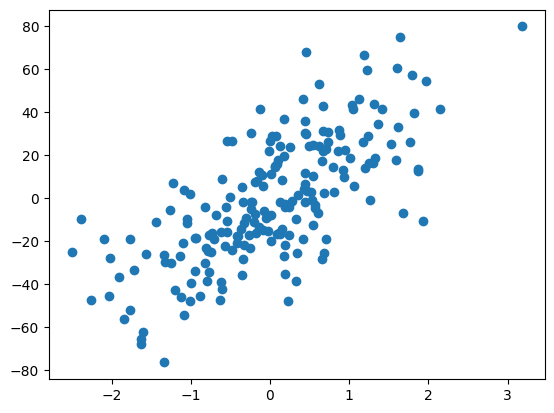

In [3]:
plt.scatter(x,y)

In [4]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [5]:
lr.fit(x,y)
print(lr.coef_,lr.intercept_)

[21.02807089] -1.3074795766522769


In [6]:
from sklearn.linear_model import Ridge
rr= Ridge(alpha=10)
rr.fit(x,y)
print(rr.coef_,rr.intercept_)

[20.00168961] -1.2924320620113412


In [7]:
rr1= Ridge(alpha=100)
rr1.fit(x,y)
print(rr1.coef_,rr1.intercept_)

[13.89690947] -1.2029314345641102


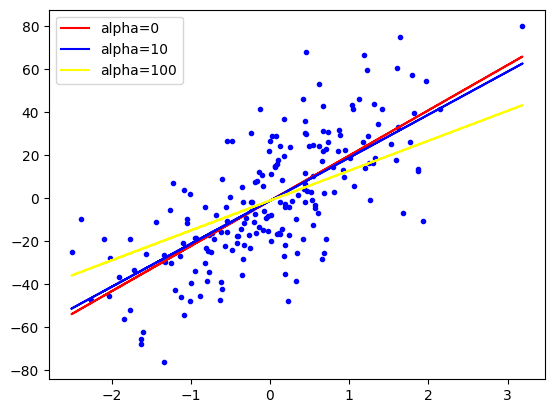

In [8]:
plt.plot(x,y,'b.')
plt.plot(x,lr.predict(x),color='red',label='alpha=0')
plt.plot(x,rr.predict(x),color='blue',label='alpha=10')
plt.plot(x,rr1.predict(x),color='yellow',label='alpha=100')
plt.legend()
plt.show()

In [9]:
class MeraRidge:
  def __init__(self,alpha=10):
    self.alpha = alpha
    self.m =None
    self.b = None
  def fit(self,x_train,y_train):
    num=0
    den=0
    for i in range(x_train.shape[0]):
      num = num + (y_train[i] - y_train.mean())*(x_train[i] - x_train.mean())
      den = den + (x_train[i] - x_train.mean())**2

    self.m = num/(den+self.alpha)
    self.b = y_train.mean() - (self.m*x_train.mean())
    print(self.m,self.b)

  def predict(self,x_test):
    return x_test * self.m + self.b

In [10]:
rr = MeraRidge()

In [11]:
rr.fit(x,y)

[20.00168961] [-1.29243206]


## ridge regression for nD data

In [12]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [13]:
x,y = load_diabetes(return_X_y=True)

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=23)

In [15]:
from sklearn.linear_model import Ridge
reg =Ridge(alpha=0.1,solver ='cholesky')

In [16]:
reg.fit(x_train,y_train)

Ridge(alpha=0.1, solver='cholesky')

In [17]:
y_pred = reg.predict(x_test)
r2_score(y_test,y_pred)

0.46699484067579355

In [18]:
print(reg.coef_)
print(reg.intercept_)

[  -2.69095639 -233.44413235  470.52984991  289.80702001  -77.44092592
  -73.76897522 -180.20544881  149.62422505  447.79211534  102.11390943]
151.38936755774745


In [29]:
class MeraRidge:
  def __init__(self,alpha=0.1):
    self.alpha = alpha
    self.coef_ = None
    self.intercept_ = None

  def fit(self,x_train,y_train):
    x_train = np.insert(x_train,0,1,axis=1)
    I = np.identity(x_train.shape[1])
    I[0][0]=0
    result = np.linalg.inv(np.dot(x_train.T,x_train)+ self.alpha*I).dot(x_train.T).dot(y_train)
    self.intercept_ = result[0]
    self.coef_ = result[1:]

  def predict(self,x_test):
    return np.dot(x_test,self.coef_) + self.intercept_



In [30]:
reg = MeraRidge()
reg.fit(x_train,y_train)
y_pred = reg.predict(x_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.4669948406757939
[  -2.69095639 -233.44413235  470.52984991  289.80702001  -77.44092592
  -73.76897522 -180.20544881  149.62422505  447.79211534  102.11390943]
151.38936755774748


In [20]:
np.insert(x_train,0,1,axis=1)

array([[ 1.        ,  0.08529891,  0.05068012, ..., -0.00259226,
         0.00286131, -0.02593034],
       [ 1.        ,  0.00538306,  0.05068012, ..., -0.00259226,
         0.03839393, -0.01350402],
       [ 1.        , -0.00188202, -0.04464164, ...,  0.08486339,
         0.08449153,  0.04862759],
       ...,
       [ 1.        ,  0.00538306,  0.05068012, ...,  0.03430886,
         0.01255119,  0.09419076],
       [ 1.        , -0.0382074 ,  0.05068012, ...,  0.071948  ,
         0.05028067,  0.06933812],
       [ 1.        , -0.0382074 , -0.04464164, ..., -0.03949338,
        -0.01599887, -0.04249877]])

In [23]:
x_train.shape

(353, 10)

In [26]:
np.identity(x_train.shape[1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])